In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_DIR = (PROJECT_ROOT / "classification" / "train").as_posix()
VAL_DIR   = (PROJECT_ROOT / "classification" / "val").as_posix()
TEST_DIR  = (PROJECT_ROOT / "classification" / "test").as_posix()

print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

TRAIN: c:/defect_cnn_project/classification/train
VAL  : c:/defect_cnn_project/classification/val
TEST : c:/defect_cnn_project/classification/test


In [16]:
import splitfolders
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"  
)

val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

N_CLASSES = len(train_data.class_indices)
class_names = list(train_data.class_indices.keys())
print("Triedy:", train_data.class_indices)

Found 1260 images belonging to 5 classes.
Found 104 images belonging to 5 classes.
Found 111 images belonging to 5 classes.
Triedy: {'bad1': 0, 'bad2': 1, 'bad3': 2, 'bad4': 3, 'good': 4}


In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(N_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

MODELS_DIR = (PROJECT_ROOT / "models")
MODELS_DIR.mkdir(exist_ok=True)
BEST_PATH = (MODELS_DIR / "cnn_multiclass_best.keras").as_posix()

callbacks = [
    EarlyStopping(patience=5, monitor="val_loss", restore_best_weights=True),
    ModelCheckpoint(BEST_PATH, monitor="val_loss", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)
print("Najlepší model uložený do:", BEST_PATH)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 526ms/step - accuracy: 0.3810 - loss: 0.4932 - val_accuracy: 0.5192 - val_loss: 0.4422
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 398ms/step - accuracy: 0.4587 - loss: 0.4528 - val_accuracy: 0.5769 - val_loss: 0.3956
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 385ms/step - accuracy: 0.5127 - loss: 0.4255 - val_accuracy: 0.5865 - val_loss: 0.3742
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 380ms/step - accuracy: 0.5349 - loss: 0.4175 - val_accuracy: 0.4712 - val_loss: 0.4201
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 383ms/step - accuracy: 0.5500 - loss: 0.4048 - val_accuracy: 0.5769 - val_loss: 0.3731
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 379ms/step - accuracy: 0.6024 - loss: 0.3763 - val_accuracy: 0.5385 - val_loss: 0.3858
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 382ms/step - accuracy: 0.5992 - loss: 0.3760 - val_accuracy: 0.5000 - val_loss: 0.4150
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 388ms/step - accuracy: 0.5976 - loss: 0.3720 - val_accu

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.6667 - loss: 0.3334
Test accuracy: 0.6666666865348816
Test loss: 0.33342376351356506
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step
              precision    recall  f1-score   support

        bad1       0.68      0.72      0.70        18
        bad2       0.55      0.50      0.52        12
        bad3       0.46      0.65      0.54        20
        bad4       0.56      0.33      0.42        15
        good       0.84      0.80      0.82        46

    accuracy                           0.67       111
   macro avg       0.62      0.60      0.60       111
weighted avg       0.68      0.67      0.67       111



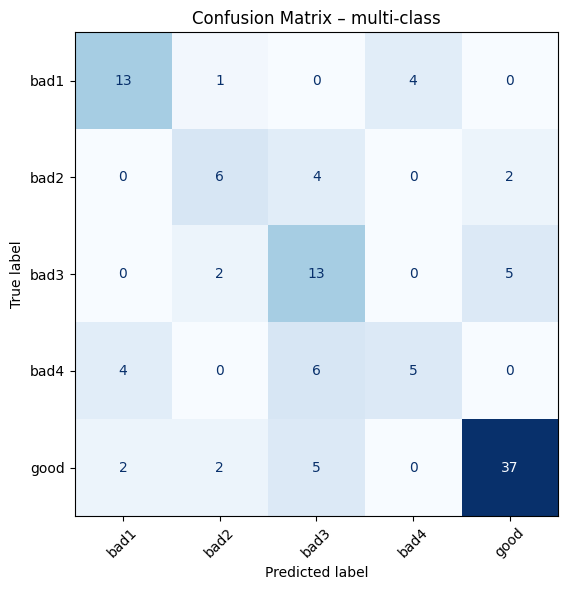

In [21]:
test_loss, test_acc = model.evaluate(test_data)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

y_true = test_data.classes
y_prob = model.predict(test_data)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – multi-class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

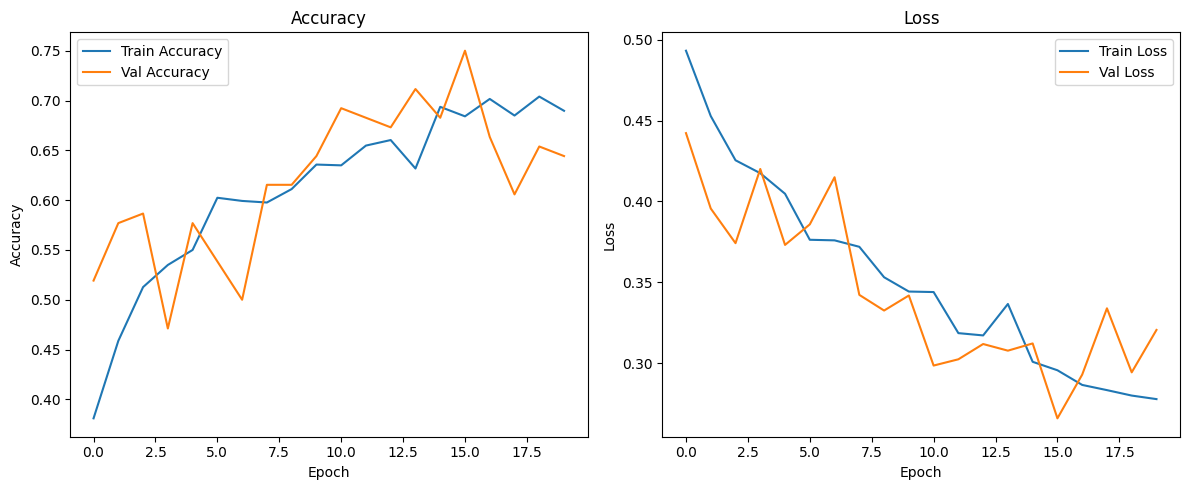

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout(); plt.show()

In [23]:
final_path = (MODELS_DIR / "cnn_multiclass_final.keras").as_posix()
model.save(final_path)
print("Finálny model uložený do:", final_path)

Finálny model uložený do: c:/defect_cnn_project/models/cnn_multiclass_final.keras
